In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from cryo_sbi.utils.infer_populations import generate_population_weights

In [2]:
models = torch.load('../../hsp90_models.pt')
rmse_values_10k = np.load('10k_rmse.npy')
pop_fractions_10k = np.load('10k_pop.npy')

rmse_values_100k = np.load('100k_rmse.npy')
pop_fractions_100k = np.load('100k_pop.npy')

In [3]:
# Here we simulate 20 models, 1207 atoms each
n_models = 20
n_atoms = 1207
# Transpose to shape (n_models, n_atoms, 3) for RMSD calculation
coords = models.cpu().numpy().transpose(0, 2, 1)

# ---------------------------
# Step 1: Define RMSD function (unweighted, unaligned)
# ---------------------------
def rmsd(P, Q):
    """
    Compute RMSD between two models without alignment.
    """
    return np.sqrt(np.mean(np.sum((P - Q)**2, axis=1)))

# RMSD of each model to the closed state (model 0)
rmsds_to_closed = np.array([rmsd(coords[0], coords[i]) for i in range(n_models)])

In [4]:
def compute_rmse_heatmaps(
    rmse_list,
    pop_fraction_list,
    rmsds_to_closed,
    models,
    population_steps=11,
):
    """
    Compute heatmaps for multiple RMSE/pop_fraction inputs.

    Parameters
    ----------
    rmse_list : list of np.ndarray
        Each element is an array of RMSE values for one run.
    pop_fraction_list : list of np.ndarray
        Each element is an array of population fractions (0-1) matching rmse_list.
    rmsds_to_closed : np.ndarray
        RMSD values for each model/state.
    models : list
        Used to determine n_states.
    population_steps : int
        Number of mixture steps (default: 11)

    Returns
    -------
    heatmaps : list of 2D np.ndarray
        One heatmap per RMSE input.
    x_levels : np.ndarray
        Sorted unique RMSD values (columns of heatmap).
    y_levels : np.ndarray
        Sorted unique population percentages (rows of heatmap).
    """

    # Precompute state indices (same for all runs)
    _, _, state_pairs = generate_population_weights(
        n_states=len(models),
        population_steps=population_steps,
    )
    state_indices = np.array([pair[1] for pair in state_pairs])

    # Precompute x-values (same for all runs)
    x_values = rmsds_to_closed[state_indices]
    x_levels = np.unique(x_values)

    heatmaps = []

    for rmse_values, pop_fractions in zip(rmse_list, pop_fraction_list):

        y_values = pop_fractions * 100  # convert to percent
        y_levels = np.unique(y_values)

        heatmap = np.zeros((len(y_levels), len(x_levels)))

        for i, y in enumerate(y_levels):
            for j, x in enumerate(x_levels):
                idx = np.where((y_values == y) & (x_values == x))[0]
                if len(idx) > 0:
                    heatmap[i, j] = rmse_values[idx[0]]

        heatmaps.append(heatmap)

    return heatmaps, x_levels, y_levels

import matplotlib.pyplot as plt

def plot_heatmap(heatmap, x_levels, y_levels, title="Heatmap"):
    plt.figure(figsize=(10, 6))
    im = plt.imshow(
        heatmap,
        origin='lower',
        aspect='auto',
        extent=[x_levels[0], x_levels[-1], y_levels[0], y_levels[-1]],
        cmap='viridis'
    )
    plt.xlabel("RMSD w.r.t closed state (Å)")
    plt.ylabel("Population of closed state (%)")
    plt.title(title)
    plt.colorbar(im, label="RMSE")
    plt.show()



In [5]:
heatmaps, x_levels, y_levels = compute_rmse_heatmaps(
    rmse_list=[rmse_values_10k, rmse_values_100k],
    pop_fraction_list=[pop_fractions_10k, pop_fractions_100k],
    rmsds_to_closed=rmsds_to_closed,
    models=models,
)
title_labels = ["10k images", "100k images"]


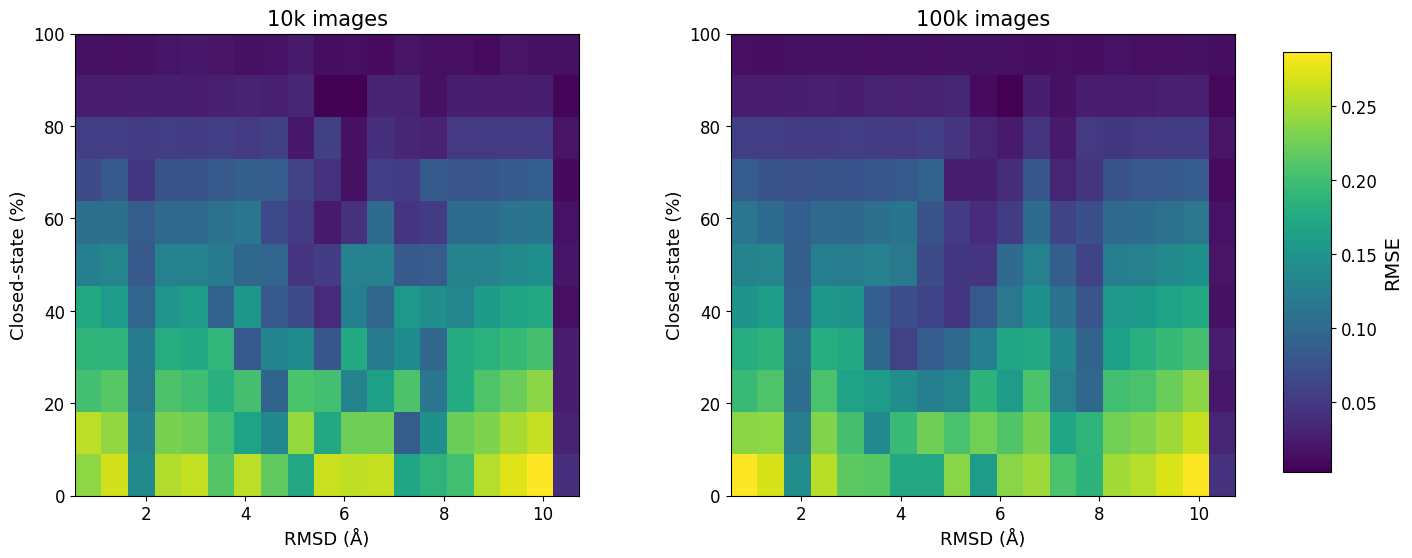

In [6]:

n_maps = len(heatmaps)
title_labels = ["10k images", "100k images"]

# Create subplots with extra space on the right for the colorbar
fig, axes = plt.subplots(1, n_maps, figsize=(16, 6))
plt.subplots_adjust(right=0.85, wspace=0.3)  # leave space for colorbar

# Plot each heatmap
for ax, hmap, label in zip(axes, heatmaps, title_labels):
    im = ax.imshow(
        hmap,
        origin='lower',
        aspect='auto',
        extent=[x_levels[0], x_levels[-1], y_levels[0], y_levels[-1]],
        cmap='viridis'
    )
    ax.set_title(label, fontsize=15)
    ax.set_xlabel("RMSD (Å)", fontsize=13)
    ax.set_ylabel("Closed-state (%)", fontsize=13)
    ax.tick_params(axis='both', labelsize=12)

# Add a single colorbar to the right
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("RMSE", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.show()
